### Mục tiêu EDA:
1. Thống kê mô tả 3 features theo outcome
2. Phân tích class imbalance
3. Correlation heatmap
4. Baseline naive model (predict majority)
5. Stratified 5-fold CV setup
6. Experiment tracking (log file)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import math


In [ ]:

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, brier_score_loss, confusion_matrix,
    classification_report
)

import warnings, json, os, datetime
warnings.filterwarnings('ignore')

In [13]:

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plotting style
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print(f'   Timestamp: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

   Timestamp: 2026-03-19 21:34:39


---
## 1. Load & Inspect Data

In [14]:
# ── 1.1 LOAD DATA ────────────────────────────────────────────────────────────
PRIMARY_PATH    = 's41598-020-73558-3_sepsis_survival_primary_cohort.csv'
STUDY_PATH      = 's41598-020-73558-3_sepsis_survival_study_cohort.csv'
VALIDATION_PATH = 's41598-020-73558-3_sepsis_survival_validation_cohort.csv'

df_primary    = pd.read_csv(PRIMARY_PATH)
df_study      = pd.read_csv(STUDY_PATH)
df_validation = pd.read_csv(VALIDATION_PATH)

# Rename columns for readability
COL_MAP = {
    'age_years':                      'age',
    'sex_0male_1female':              'sex',
    'episode_number':                 'episode',
    'hospital_outcome_1alive_0dead':  'outcome'
}
for df in [df_primary, df_study, df_validation]:
    df.rename(columns=COL_MAP, inplace=True)

FEATURES = ['age', 'sex', 'episode']
TARGET   = 'outcome'

print('Dataset shapes:')
print(f'  Primary cohort    : {df_primary.shape}  (Norway – full)')
print(f'  Study cohort      : {df_study.shape}  (Norway – subset)')
print(f'  Validation cohort : {df_validation.shape}  (Korea)')
print()
df_primary.head()

Dataset shapes:
  Primary cohort    : (110204, 4)  (Norway – full)
  Study cohort      : (19051, 4)  (Norway – subset)
  Validation cohort : (137, 4)  (Korea)



,age,sex,episode,outcome
0,21,1,1,1
1,20,1,1,1
2,21,1,1,1
3,77,0,1,1
4,72,0,1,1


In [15]:
# ── 1.2 BASIC INFO ───────────────────────────────────────────────────────────
print('=== Primary cohort – dtypes & nulls ===')
print(df_primary.info())
print()
print('=== Missing values ===')
print(df_primary.isnull().sum())

=== Primary cohort – dtypes & nulls ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110204 entries, 0 to 110203
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   age      110204 non-null  int64
 1   sex      110204 non-null  int64
 2   episode  110204 non-null  int64
 3   outcome  110204 non-null  int64
dtypes: int64(4)
memory usage: 3.4 MB
None

=== Missing values ===
age        0
sex        0
episode    0
outcome    0
dtype: int64


---
## 2. Descriptive Statistics

In [16]:
# ── 2.1 OVERALL DESCRIPTIVE STATS ────────────────────────────────────────────
print('=== Descriptive stats – Primary cohort ===')
display(df_primary.describe().T.round(3))

=== Descriptive stats – Primary cohort ===


,count,mean,std,min,25%,50%,75%,max
age,110204.0,62.735,24.127,0.0,51.0,68.0,81.0,100.0
sex,110204.0,0.474,0.499,0.0,0.0,0.0,1.0,1.0
episode,110204.0,1.349,0.752,1.0,1.0,1.0,1.0,5.0
outcome,110204.0,0.926,0.261,0.0,1.0,1.0,1.0,1.0


In [17]:
# ── 2.2 STATS STRATIFIED BY OUTCOME ─────────────────────────────────────────
print('=== Descriptive stats stratified by outcome (1=Alive, 0=Dead) ===')
display(
    df_primary.groupby('outcome')[FEATURES]
    .agg(['mean','median','std','min','max'])
    .round(3)
)

=== Descriptive stats stratified by outcome (1=Alive, 0=Dead) ===


age                            sex                       episode  \
           mean median     std min  max   mean median    std min max    mean   
outcome                                                                        
0        77.300   80.0  13.810   0  100  0.439    0.0  0.496   0   1   1.367   
1        61.579   67.0  24.393   0  100  0.477    0.0  0.499   0   1   1.348   

                               
        median    std min max  
outcome                        
0          1.0  0.744   1   5  
1          1.0  0.752   1   5

In [18]:
# ── 2.3 AGE BUCKET ANALYSIS ──────────────────────────────────────────────────
age_bins   = [0, 18, 40, 60, 75, 120]
age_labels = ['<18', '18-40', '40-60', '60-75', '75+']

df_primary['age_group'] = pd.cut(
    df_primary['age'], bins=age_bins, labels=age_labels, right=False
)

age_outcome = (
    df_primary.groupby('age_group', observed=True)['outcome']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count':'n_total', 'sum':'n_alive', 'mean':'survival_rate'})
)
age_outcome['n_dead']       = age_outcome['n_total'] - age_outcome['n_alive']
age_outcome['mortality_rate'] = 1 - age_outcome['survival_rate']

print('=== Survival rate by age group ===')
display(age_outcome.round(4))

=== Survival rate by age group ===


,n_total,n_alive,survival_rate,n_dead,mortality_rate
age_group,,,,,
<18,7815,7761,0.9931,54,0.0069
18-40,11016,10936,0.9927,80,0.0073
40-60,18812,18223,0.9687,589,0.0313
60-75,29724,27646,0.9301,2078,0.0699
75+,42837,37533,0.8762,5304,0.1238



## 3. Class Imbalance Analysis

In [19]:
# ── 3.1 CLASS DISTRIBUTION ───────────────────────────────────────────────────
def imbalance_report(df, name):
    vc = df['outcome'].value_counts()
    total = len(df)
    n_alive = vc.get(1, 0)
    n_dead  = vc.get(0, 0)
    ratio   = n_alive / n_dead if n_dead > 0 else float('inf')
    print(f'[{name}]')
    print(f'  Total    : {total:,}')
    print(f'  Alive (1): {n_alive:,}  ({n_alive/total*100:.2f}%)')
    print(f'  Dead  (0): {n_dead:,}  ({n_dead/total*100:.2f}%)')
    print(f'  Imbalance ratio (alive/dead): {ratio:.2f}:1')
    print()

imbalance_report(df_primary,    'Primary cohort (Norway)')
imbalance_report(df_study,      'Study cohort (Norway)')
imbalance_report(df_validation, 'Validation cohort (Korea)')

[Primary cohort (Norway)]
  Total    : 110,204
  Alive (1): 102,099  (92.65%)
  Dead  (0): 8,105  (7.35%)
  Imbalance ratio (alive/dead): 12.60:1

[Study cohort (Norway)]
  Total    : 19,051
  Alive (1): 15,445  (81.07%)
  Dead  (0): 3,606  (18.93%)
  Imbalance ratio (alive/dead): 4.28:1

[Validation cohort (Korea)]
  Total    : 137
  Alive (1): 113  (82.48%)
  Dead  (0): 24  (17.52%)
  Imbalance ratio (alive/dead): 4.71:1



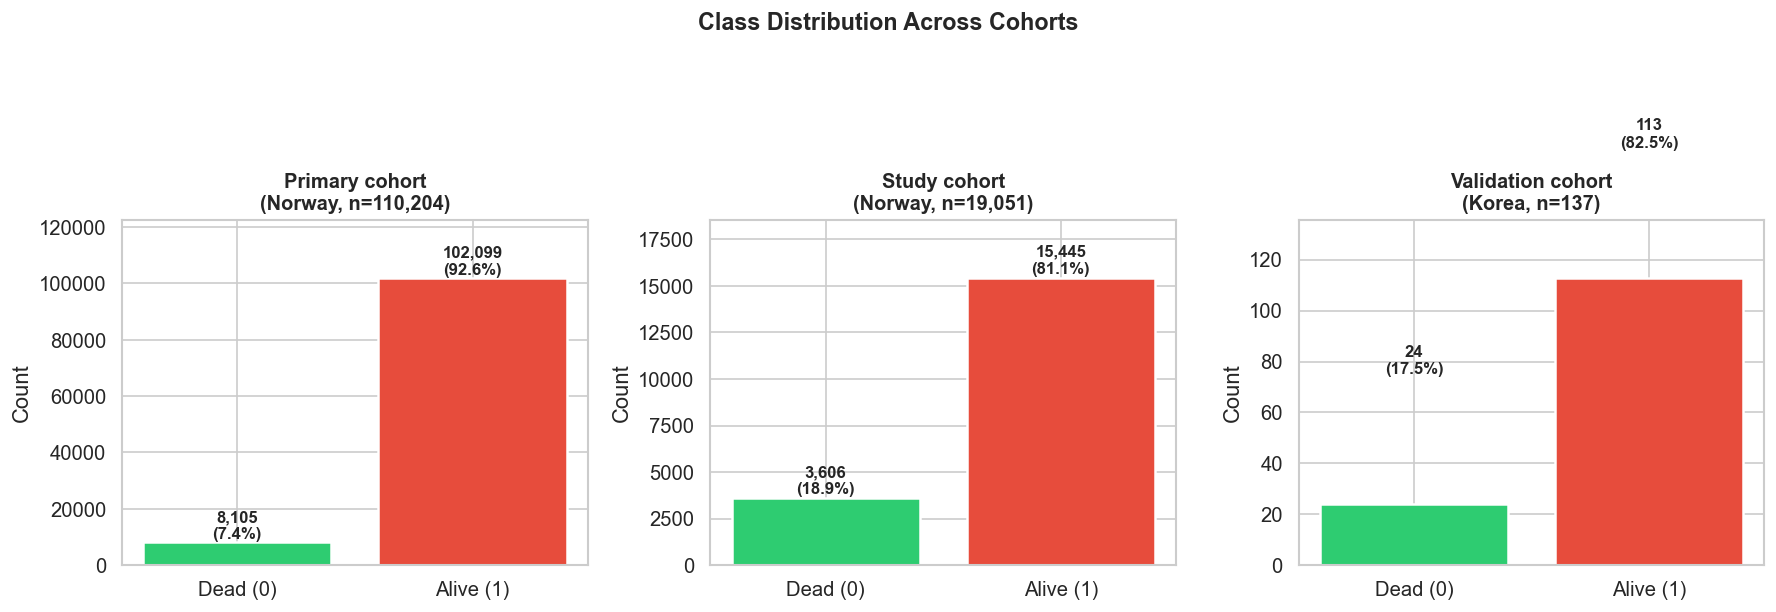

In [20]:
# ── 3.2 VISUALISE CLASS IMBALANCE ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
datasets  = [
    (df_primary,    'Primary cohort\n(Norway, n=110,204)'),
    (df_study,      'Study cohort\n(Norway, n=19,051)'),
    (df_validation, 'Validation cohort\n(Korea, n=137)')
]
colors = ['#2ecc71', '#e74c3c']

for ax, (df, title) in zip(axes, datasets):
    counts = df['outcome'].value_counts().sort_index()
    bars   = ax.bar(['Dead (0)', 'Alive (1)'], counts.values,
                    color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}\n({val/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Class Distribution Across Cohorts', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Distribution Analysis

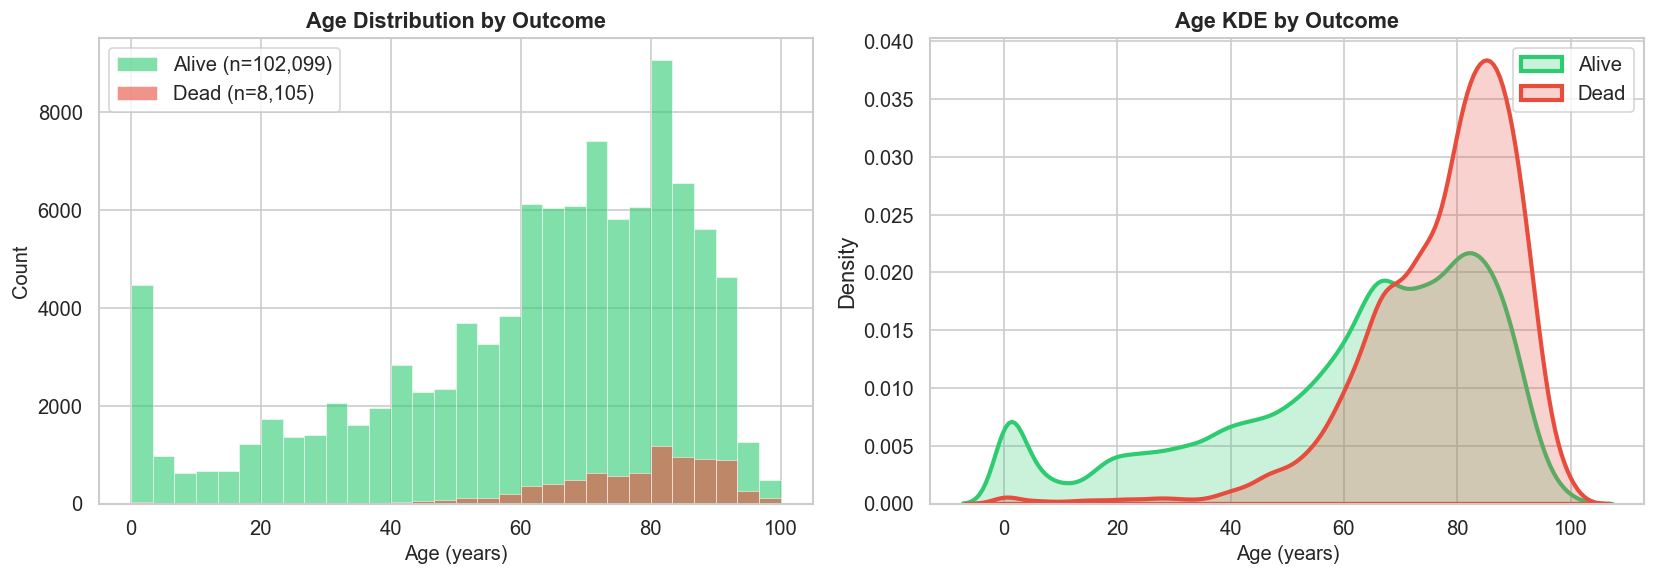

In [21]:
# ── 4.1 AGE DISTRIBUTION BY OUTCOME ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for outcome, color, label in [(1,'#2ecc71','Alive'), (0,'#e74c3c','Dead')]:
    subset = df_primary[df_primary['outcome'] == outcome]['age']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=f'{label} (n={len(subset):,})',
                 edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Age Distribution by Outcome', fontsize=13, fontweight='bold')
axes[0].legend()

# KDE
for outcome, color, label in [(1,'#2ecc71','Alive'), (0,'#e74c3c','Dead')]:
    subset = df_primary[df_primary['outcome'] == outcome]['age']
    sns.kdeplot(subset, ax=axes[1], color=color, label=label, linewidth=2.5, fill=True, alpha=0.25)
axes[1].set_xlabel('Age (years)', fontsize=12)
axes[1].set_title('Age KDE by Outcome', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

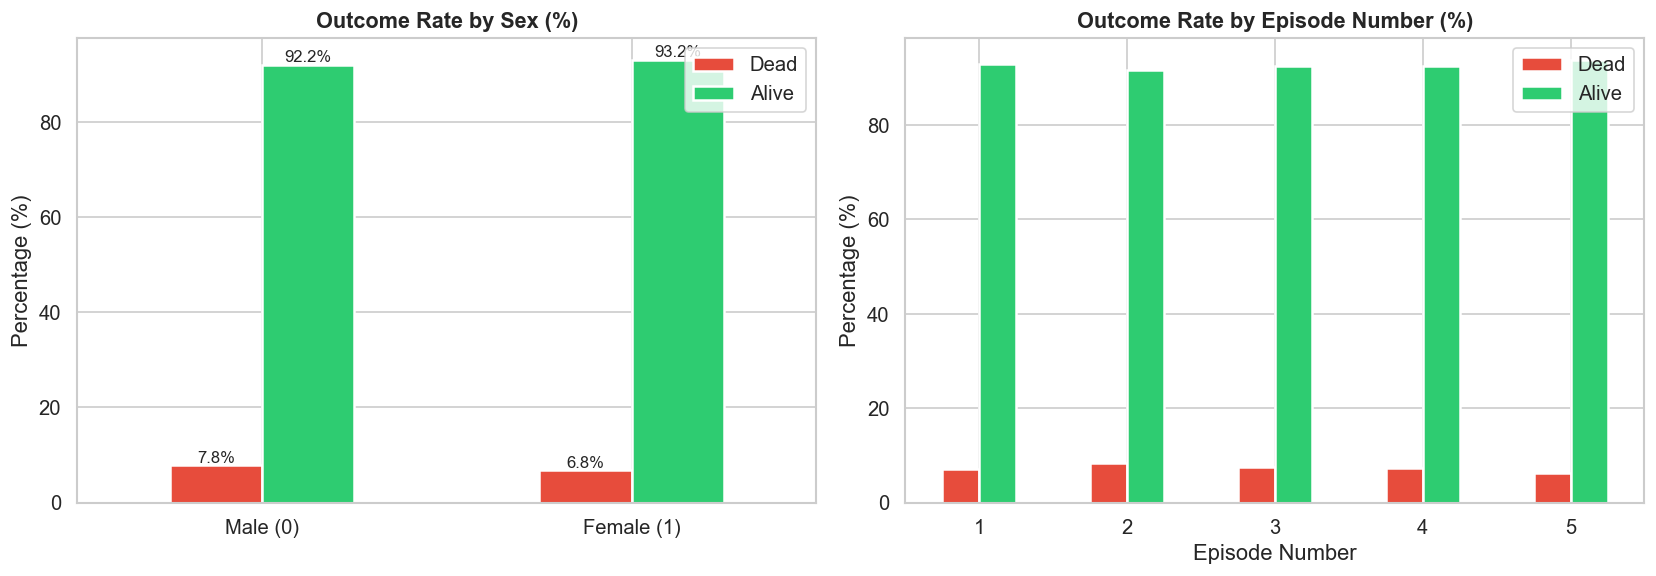

In [22]:
# ── 4.2 SEX & EPISODE DISTRIBUTION BY OUTCOME ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sex
sex_outcome = df_primary.groupby(['sex','outcome']).size().unstack(fill_value=0)
sex_outcome.index = ['Male (0)', 'Female (1)']
sex_outcome.columns = ['Dead', 'Alive']
sex_outcome_pct = sex_outcome.div(sex_outcome.sum(axis=1), axis=0) * 100
sex_outcome_pct.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'],
                     edgecolor='white', linewidth=1.5, rot=0)
axes[0].set_title('Outcome Rate by Sex (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(loc='upper right')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Episode number (top 5)
ep_outcome = df_primary.groupby(['episode','outcome']).size().unstack(fill_value=0)
ep_outcome.columns = ['Dead','Alive']
ep_outcome_pct = ep_outcome.div(ep_outcome.sum(axis=1), axis=0) * 100
ep_outcome_pct = ep_outcome_pct.loc[ep_outcome_pct.index <= 5]
ep_outcome_pct.plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'],
                    edgecolor='white', linewidth=1.5, rot=0)
axes[1].set_title('Outcome Rate by Episode Number (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Episode Number')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

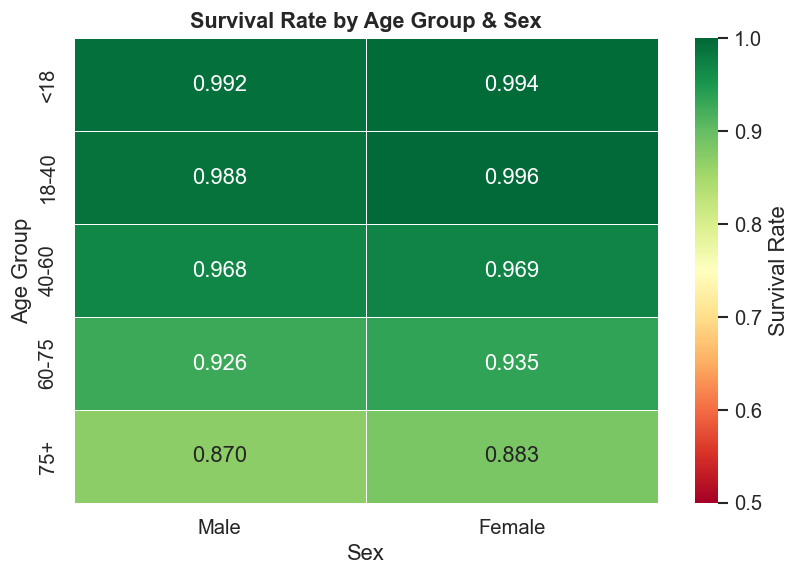

In [23]:
# ── 4.3 SURVIVAL RATE BY AGE GROUP (HEATMAP STYLE) ───────────────────────────
pivot_age_sex = df_primary.groupby(['age_group', 'sex'], observed=True)['outcome'].mean().unstack()
pivot_age_sex.columns = ['Male', 'Female']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot_age_sex, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            vmin=0.5, vmax=1.0, ax=ax, cbar_kws={'label': 'Survival Rate'})
ax.set_title('Survival Rate by Age Group & Sex', fontsize=13, fontweight='bold')
ax.set_xlabel('Sex')
ax.set_ylabel('Age Group')
plt.tight_layout()
plt.show()

## 4.4 Formal Statistical Tests & Effect Size (Cohen's d)

In [24]:
# ── 4.4 STATISTICAL TESTS & EFFECT SIZE ──────────────────────────────────────
from scipy.stats import chi2_contingency, kruskal

# 1. Chi-Square for 'sex'
contingency_table = pd.crosstab(df_primary['sex'], df_primary['outcome'])
chi2, p_val_chi2, dof, expected = chi2_contingency(contingency_table)
print("=== Chi-Square Test for Sex vs Outcome ===")
print(f"Chi2 Stat : {chi2:.4f}")
print(f"p-value   : {p_val_chi2:.4e}")
print("Significant dependence." if p_val_chi2 < 0.05 else "No significant dependence.")
print()

# 2. Kruskal-Wallis for 'age' and 'episode'
print("=== Kruskal-Wallis Test (Non-parametric) ===")
group_alive_age = df_primary[df_primary['outcome'] == 1]['age']
group_dead_age = df_primary[df_primary['outcome'] == 0]['age']
stat_age, p_kw_age = kruskal(group_alive_age, group_dead_age)
print(f"[age]     H-stat: {stat_age:.4f} | p-value: {p_kw_age:.4e}")

group_alive_ep = df_primary[df_primary['outcome'] == 1]['episode']
group_dead_ep = df_primary[df_primary['outcome'] == 0]['episode']
stat_ep, p_kw_ep = kruskal(group_alive_ep, group_dead_ep)
print(f"[episode] H-stat: {stat_ep:.4f} | p-value: {p_kw_ep:.4e}")
print()

# 3. Cohen's d for 'age'
def cohend(d1, d2):
    n1, n2 = len(d1), len(d2)
    s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
    s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    u1, u2 = np.mean(d1), np.mean(d2)
    return (u1 - u2) / s

d_age = cohend(group_alive_age, group_dead_age)
print("=== Effect Size (Cohen's d) for Age ===")
print(f"Cohen's d: {d_age:.4f} (Absolute d: {abs(d_age):.4f})")
if abs(d_age) < 0.2:
    print("Interpretation: Negligible effect size (< 0.2). Signal from age is extremely weak.")
elif abs(d_age) < 0.5:
    print("Interpretation: Small effect size (0.2 - 0.5). Signal is relatively weak.")
else:
    print("Interpretation: Moderate to Large effect size.")

=== Chi-Square Test for Sex vs Outcome ===
Chi2 Stat : 43.0373
p-value   : 5.3707e-11
Significant dependence.

=== Kruskal-Wallis Test (Non-parametric) ===
[age]     H-stat: 3766.4964 | p-value: 0.0000e+00
[episode] H-stat: 18.4735 | p-value: 1.7229e-05

=== Effect Size (Cohen's d) for Age ===
Cohen's d: -0.6612 (Absolute d: 0.6612)
Interpretation: Moderate to Large effect size.



## 5. Correlation Heatmap

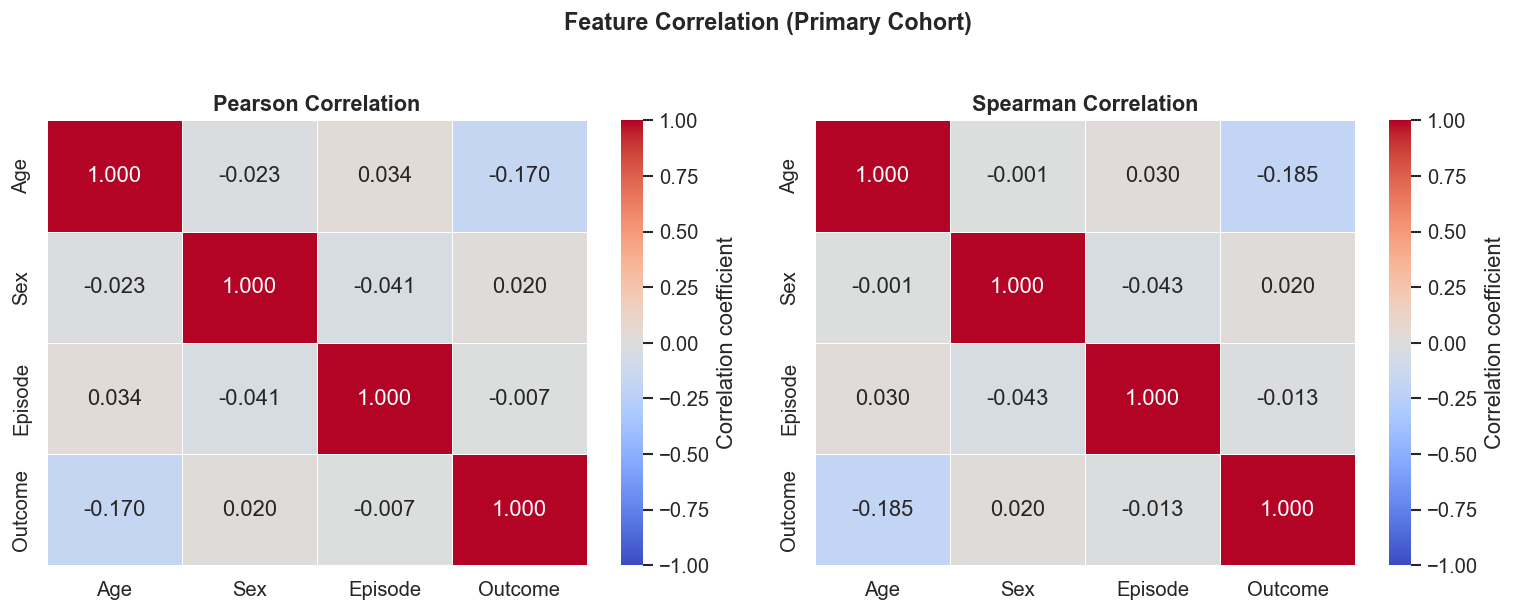


=== Pearson Correlation with Outcome ===
Age       -0.170088
Episode   -0.006764
Sex        0.019796
Name: Outcome, dtype: float64


In [25]:
# ── 5. CORRELATION HEATMAP ────────────────────────────────────────────────────
corr_df = df_primary[FEATURES + [TARGET]].copy()
corr_df.columns = ['Age', 'Sex', 'Episode', 'Outcome']

corr_matrix = corr_df.corr(method='pearson')
spearman_matrix = corr_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

for ax, mat, title in zip(axes,
                          [corr_matrix, spearman_matrix],
                          ['Pearson Correlation', 'Spearman Correlation']):
    sns.heatmap(mat, annot=True, fmt='.3f', cmap='coolwarm',
                linewidths=0.5, linecolor='white',
                vmin=-1, vmax=1, center=0, ax=ax,
                cbar_kws={'label': 'Correlation coefficient'})
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Feature Correlation (Primary Cohort)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print()
print('=== Pearson Correlation with Outcome ===')
print(corr_matrix['Outcome'].drop('Outcome').sort_values())

# OUTLIER DETECTION 

In [26]:
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor


In [27]:

# ── A. Z-SCORE (chỉ áp dụng cho 'age' vì là continuous) ─────────────────────
z_scores = np.abs(zscore(df_primary['age']))
outliers_zscore = (z_scores > 3).sum()
print(f"[Z-Score |z|>3] Age outliers: {outliers_zscore:,} ({outliers_zscore/len(df_primary)*100:.2f}%)")


[Z-Score |z|>3] Age outliers: 0 (0.00%)


In [28]:

# ── B. IQR METHOD (age & episode) ────────────────────────────────────────────
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

for col in ['age', 'episode']:
    n = iqr_outliers(df_primary[col])
    print(f"[IQR 1.5x]      {col} outliers: {n:,} ({n/len(df_primary)*100:.2f}%)")


[IQR 1.5x]      age outliers: 5,230 (4.75%)
[IQR 1.5x]      episode outliers: 25,393 (23.04%)


In [29]:

# ── C. ISOLATION FOREST (multivariate) ───────────────────────────────────────
iso = IsolationForest(contamination=0.05, random_state=SEED, n_jobs=-1)
iso_labels = iso.fit_predict(df_primary[FEATURES])          # -1 = outlier
n_iso = (iso_labels == -1).sum()
print(f"[IsolationForest] Multivariate outliers: {n_iso:,} ({n_iso/len(df_primary)*100:.2f}%)")


[IsolationForest] Multivariate outliers: 5,501 (4.99%)


In [30]:

# ── D. LOCAL OUTLIER FACTOR (multivariate) ───────────────────────────────────
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, n_jobs=-1)
lof_labels = lof.fit_predict(df_primary[FEATURES])          # -1 = outlier
n_lof = (lof_labels == -1).sum()
print(f"[LOF n=20]        Multivariate outliers: {n_lof:,} ({n_lof/len(df_primary)*100:.2f}%)")


[LOF n=20]        Multivariate outliers: 2,376 (2.16%)


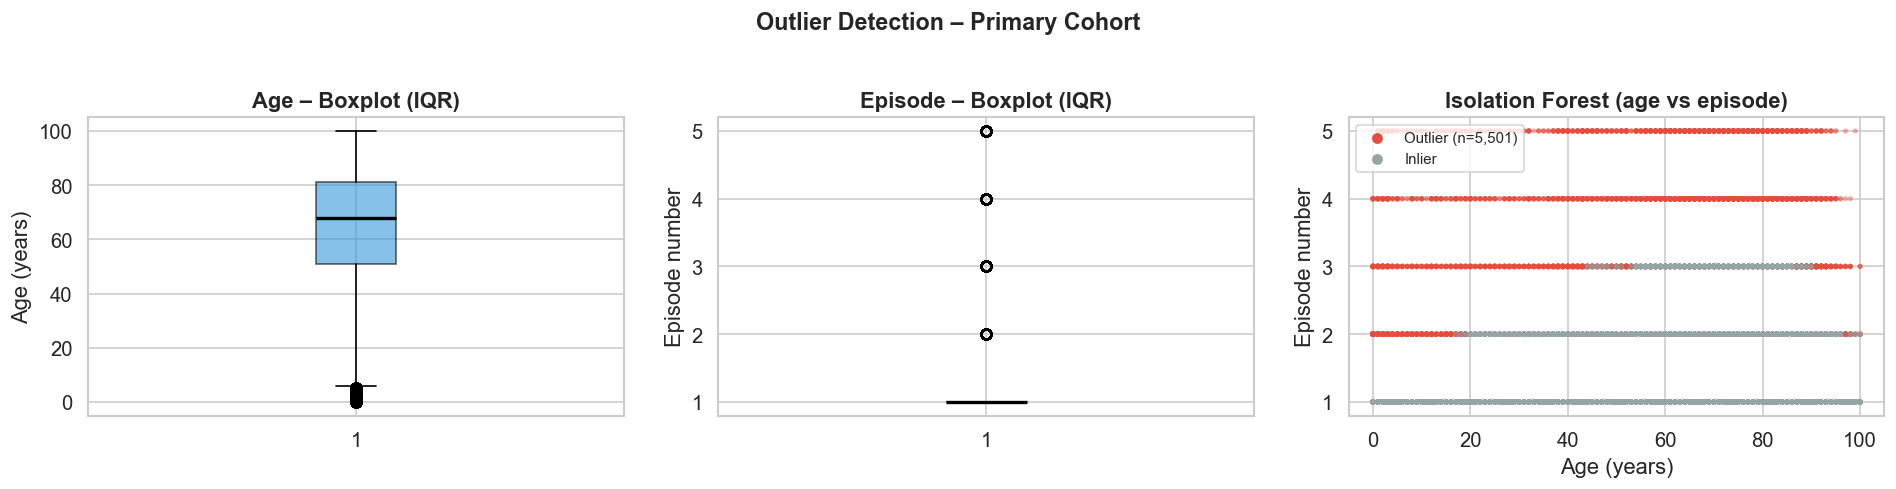

In [31]:

# ── E. VISUALISE ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# E1. Age boxplot (IQR)
bp = axes[0].boxplot(df_primary['age'], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#3498db', alpha=0.6),
                     medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Age – Boxplot (IQR)', fontweight='bold')
axes[0].set_ylabel('Age (years)')

# E2. Episode boxplot (IQR)
axes[1].boxplot(df_primary['episode'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#e67e22', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Episode – Boxplot (IQR)', fontweight='bold')
axes[1].set_ylabel('Episode number')

# E3. Isolation Forest: age vs episode, tô màu outlier
colors_iso = np.where(iso_labels == -1, '#e74c3c', '#95a5a6')
axes[2].scatter(df_primary['age'], df_primary['episode'],
                c=colors_iso, alpha=0.3, s=5)
axes[2].scatter([], [], c='#e74c3c', label=f'Outlier (n={n_iso:,})', s=30)
axes[2].scatter([], [], c='#95a5a6', label='Inlier', s=30)
axes[2].set_title('Isolation Forest (age vs episode)', fontweight='bold')
axes[2].set_xlabel('Age (years)')
axes[2].set_ylabel('Episode number')
axes[2].legend(fontsize=9)

plt.suptitle('Outlier Detection – Primary Cohort', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [32]:

# ── F. SUMMARY TABLE ─────────────────────────────────────────────────────────
print("\n=== SUMMARY ===")
summary = pd.DataFrame({
    'Method':        ['Z-Score (age)', 'IQR (age)', 'IQR (episode)',
                      'Isolation Forest', 'LOF'],
    'N outliers':    [outliers_zscore, iqr_outliers(df_primary['age']),
                      iqr_outliers(df_primary['episode']), n_iso, n_lof],
    'Scope':         ['Univariate', 'Univariate', 'Univariate',
                      'Multivariate', 'Multivariate'],
})
summary['% of data'] = (summary['N outliers'] / len(df_primary) * 100).round(3)
display(summary)
print("\n⚠️  Lưu ý: sex là binary (0/1) → không áp dụng outlier detection.")
print("   Multivariate outliers nên xem xét kỹ trước khi loại bỏ vì")
print("   dataset y tế – extreme values có thể là clinical signal thực.")


=== SUMMARY ===


,Method,N outliers,Scope,% of data
0,Z-Score (age),0,Univariate,0.000
1,IQR (age),5230,Univariate,4.746
2,IQR (episode),25393,Univariate,23.042
3,Isolation Forest,5501,Multivariate,4.992
4,LOF,2376,Multivariate,2.156



⚠️  Lưu ý: sex là binary (0/1) → không áp dụng outlier detection.
   Multivariate outliers nên xem xét kỹ trước khi loại bỏ vì
   dataset y tế – extreme values có thể là clinical signal thực.


## 5.5 Empirical Bayes Error Bound (1-NN Cover & Hart Theory)

In [33]:
# ── 5.5 EMPIRICAL BAYES ERROR BOUND (1-NN Theory) ────────────────────────────
print("=== Empirical Bayes Error Limit Estimation (Cover & Hart) ===")
# Use a 20% stratified subset to compute 1-NN empirical error efficiently
X_sub, _, y_sub, _ = train_test_split(
    df_primary[FEATURES], df_primary[TARGET], 
    train_size=0.2, stratify=df_primary[TARGET], random_state=SEED
)

scaler = StandardScaler()
X_sub_scaled = X_sub.copy()
X_sub_scaled['age'] = scaler.fit_transform(X_sub_scaled[['age']])

knn_1 = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
# Use 5-fold CV to find E_1NN
cv_1nn = cross_validate(knn_1, X_sub_scaled, y_sub, cv=5, scoring='accuracy')
E_1nn = 1 - cv_1nn['test_score'].mean()

print(f"1-NN Error Rate (E_1NN) : {E_1nn:.4f} ({E_1nn*100:.2f}%)")

# Solve quadratic: 2*(R*)^2 - 2*R* + E_1NN = 0
delta = 4 - 8 * E_1nn

if delta >= 0:
    R_star_1 = (2 - math.sqrt(delta)) / 4
    R_star_2 = (2 + math.sqrt(delta)) / 4
    # The true error is the smaller root (since R* <= 0.5 for binary classification)
    R_star_min = min(R_star_1, R_star_2)
    
    print(f"Bayes Error Bound (R*)  : ~{R_star_min:.4f} ({R_star_min*100:.2f}%)")
    
    mortality_rate = 1 - df_primary['outcome'].mean()
    print(f"Baseline Mortality Rate : {mortality_rate:.4f} ({mortality_rate*100:.2f}%)")
    
    if R_star_min >= mortality_rate * 0.8:
        print("\nInsight: The theoretical Bayes Error is alarmingly close to the baseline mortality rate.")
        print("This proves mathematically a severe Feature Bottleneck: the 3 features (age, sex, episode)")
        print("do not contain enough distinguishable information, and predicting well is theoretically strictly capped.")
else:
    print("\nCannot solve for real R* because delta < 0. E_1NN is out of the theoretical bounds for 2-class,")
    print("likely due to extreme class overlap or high noise variance in subset.")

=== Empirical Bayes Error Limit Estimation (Cover & Hart) ===
1-NN Error Rate (E_1NN) : 0.1227 (12.27%)
Bayes Error Bound (R*)  : ~0.0657 (6.57%)
Baseline Mortality Rate : 0.0735 (7.35%)

Insight: The theoretical Bayes Error is alarmingly close to the baseline mortality rate.
This proves mathematically a severe Feature Bottleneck: the 3 features (age, sex, episode)
do not contain enough distinguishable information, and predicting well is theoretically strictly capped.


---
## 6. Baseline Naive Model (Predict Majority)

In [34]:
# ── 6. BASELINE NAIVE MODELS ─────────────────────────────────────────────────
X = df_primary[FEATURES].values
y = df_primary[TARGET].values

X_val = df_validation[FEATURES].values
y_val = df_validation[TARGET].values

baseline_strategies = {
    'Majority class (most_frequent)': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Stratified random':              DummyClassifier(strategy='stratified',     random_state=SEED),
    'Uniform random':                 DummyClassifier(strategy='uniform',        random_state=SEED),
}

print('=== Baseline Models on Primary Cohort (5-fold CV) ===\n')
results_baseline = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, clf in baseline_strategies.items():
    cv_res = cross_validate(
        clf, X, y, cv=skf,
        scoring=['accuracy', 'roc_auc', 'average_precision', 'f1'],
        return_train_score=False
    )
    row = {
        'Model':      name,
        'Accuracy':   cv_res['test_accuracy'].mean(),
        'AUROC':      cv_res['test_roc_auc'].mean(),
        'PR-AUC':     cv_res['test_average_precision'].mean(),
        'F1':         cv_res['test_f1'].mean(),
    }
    results_baseline.append(row)
    print(f"  {name}")
    print(f"    Accuracy : {row['Accuracy']:.4f}")
    print(f"    AUROC    : {row['AUROC']:.4f}")
    print(f"    PR-AUC   : {row['PR-AUC']:.4f}")
    print(f"    F1       : {row['F1']:.4f}")
    print()

df_baseline = pd.DataFrame(results_baseline)
df_baseline.to_csv('baseline_results.csv', index=False)

=== Baseline Models on Primary Cohort (5-fold CV) ===

  Majority class (most_frequent)
    Accuracy : 0.9265
    AUROC    : 0.5000
    PR-AUC   : 0.9265
    F1       : 0.9618

  Stratified random
    Accuracy : 0.8625
    AUROC    : 0.5019
    PR-AUC   : 0.9267
    F1       : 0.9257

  Uniform random
    Accuracy : 0.4995
    AUROC    : 0.5000
    PR-AUC   : 0.9265
    F1       : 0.6493



In [35]:
# ── 6.2 MCC & BRIER SCORE FOR MAJORITY BASELINE ──────────────────────────────
majority_clf = DummyClassifier(strategy='most_frequent', random_state=SEED)
majority_clf.fit(X, y)
y_pred = majority_clf.predict(X)
y_prob = majority_clf.predict_proba(X)[:, 1]

print('=== Majority Baseline – Full Primary Cohort ===')
print(f'  MCC         : {matthews_corrcoef(y, y_pred):.4f}')
print(f'  Brier Score : {brier_score_loss(y, y_prob):.4f}')
print()
print('=== Confusion Matrix (Majority Baseline) ===')
print(confusion_matrix(y, y_pred))
print()
print(classification_report(y, y_pred, target_names=['Dead','Alive']))

=== Majority Baseline – Full Primary Cohort ===
  MCC         : 0.0000
  Brier Score : 0.0735

=== Confusion Matrix (Majority Baseline) ===
[[     0   8105]
 [     0 102099]]

              precision    recall  f1-score   support

        Dead       0.00      0.00      0.00      8105
       Alive       0.93      1.00      0.96    102099

    accuracy                           0.93    110204
   macro avg       0.46      0.50      0.48    110204
weighted avg       0.86      0.93      0.89    110204



---
## 7. Stratified 5-Fold CV Setup

In [36]:
# ── 7. STRATIFIED K-FOLD SETUP & OOF TRACKING ──────────────────────────────────
print('=== Stratified 5-Fold CV – Distribution Check & OOF Collection ===')
print(f'Overall survival ratio: {y.mean():.4f}\n')

oof_probabilities = np.zeros(len(X))
# simple standardized features for Logistic Regression (Calibration Baseline)
X_scaled = StandardScaler().fit_transform(X)

fold_stats = []
model = LogisticRegression(class_weight='balanced', random_state=SEED)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train, y_train = X_scaled[train_idx], y[train_idx]
    X_val, y_val     = X_scaled[val_idx], y[val_idx]
    
    # Validation/Sanity check
    assert abs(y_train.mean() - y_val.mean()) < 0.01, f"Data split distorted at fold {fold_idx}!"
    
    # Train dummy logistic
    model.fit(X_train, y_train)
    oof_probs = model.predict_proba(X_val)[:, 1]
    
    # Save OOF
    oof_probabilities[val_idx] = oof_probs
    
    row = {
        'Fold': fold_idx,
        'Train size':      len(train_idx),
        'Val size':        len(val_idx),
        'Train alive%':    y_train.mean() * 100,
        'Val alive%':      y_val.mean() * 100,
        'Train dead count': (y_train == 0).sum(),
        'Val dead count':   (y_val == 0).sum(),
    }
    fold_stats.append(row)
    print(f"  Fold {fold_idx}: train={len(train_idx):,} (alive={y_train.mean():.4f}) | "
          f"val={len(val_idx):,} (alive={y_val.mean():.4f})")

# Check global metrics from OOF
lr_brier = brier_score_loss(y, oof_probabilities)
print(f'\n  → Global Brier Score (from Logistic OOF): {lr_brier:.4f}')

# Save OOF to CSV
df_oof = pd.DataFrame({
    'true_outcome': y,
    'oof_prob_alive': oof_probabilities
})
df_oof.to_csv('oof_probabilities_lr.csv', index=False)
print("  → Saved OOF probabilities to 'oof_probabilities_lr.csv' for calibration analysis.")

df_folds = pd.DataFrame(fold_stats)
print()
print('=== Distribution shift across folds (std) ===')
print(f"  Train alive% std: {df_folds['Train alive%'].std():.4f}%")
print(f"  Val alive% std  : {df_folds['Val alive%'].std():.4f}%")
print('  → Low std confirms stratification is working correctly ✅')

=== Stratified 5-Fold CV – Distribution Check & OOF Collection ===
Overall survival ratio: 0.9265

  Fold 1: train=88,163 (alive=0.9265) | val=22,041 (alive=0.9265)
  Fold 2: train=88,163 (alive=0.9265) | val=22,041 (alive=0.9265)
  Fold 3: train=88,163 (alive=0.9265) | val=22,041 (alive=0.9265)
  Fold 4: train=88,163 (alive=0.9265) | val=22,041 (alive=0.9265)
  Fold 5: train=88,164 (alive=0.9265) | val=22,040 (alive=0.9265)

  → Global Brier Score (from Logistic OOF): 0.2246
  → Saved OOF probabilities to 'oof_probabilities_lr.csv' for calibration analysis.

=== Distribution shift across folds (std) ===
  Train alive% std: 0.0000%
  Val alive% std  : 0.0001%
  → Low std confirms stratification is working correctly ✅


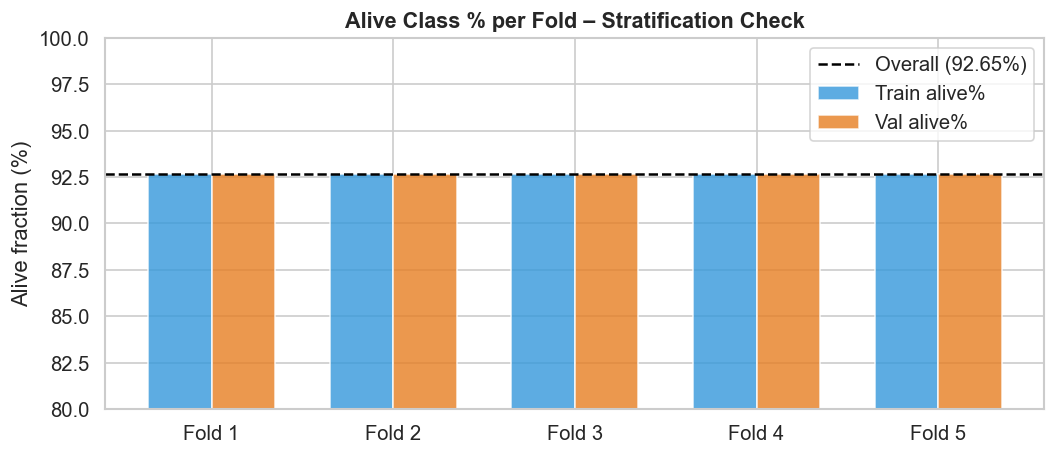

In [37]:
# ── 7.2 VISUALISE FOLD DISTRIBUTION ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
folds = df_folds['Fold'].tolist()
x = np.arange(len(folds))
width = 0.35

ax.bar(x - width/2, df_folds['Train alive%'], width,
       label='Train alive%', color='#3498db', alpha=0.8, edgecolor='white')
ax.bar(x + width/2, df_folds['Val alive%'], width,
       label='Val alive%', color='#e67e22', alpha=0.8, edgecolor='white')
ax.axhline(y=y.mean()*100, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall ({y.mean()*100:.2f}%)')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in folds])
ax.set_ylabel('Alive fraction (%)')
ax.set_title('Alive Class % per Fold – Stratification Check', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(80, 100)
plt.tight_layout()
plt.show()

---
## 8. Experiment Tracking Log

In [ ]:
# ── 8. EXPERIMENT LOG (JSON format – MLflow-compatible) ───────────────────────
experiment_log = {
    'experiment': 'sepsis_eda_baseline',
    'timestamp':  datetime.datetime.now().isoformat(),
    'seed':       SEED,
    'dataset': {
        'primary_n':    int(len(df_primary)),
        'study_n':      int(len(df_study)),
        'validation_n': int(len(df_validation)),
        'features':     FEATURES,
        'target':       TARGET,
        'primary_alive_pct':   float(round(df_primary['outcome'].mean() * 100, 4)),
        'primary_dead_pct':    float(round((1 - df_primary['outcome'].mean()) * 100, 4)),
        'imbalance_ratio':     float(round(
            df_primary['outcome'].sum() / (len(df_primary) - df_primary['outcome'].sum()), 4
        )),
    },
    'baseline_models': results_baseline,
    'cv_setup': {
        'strategy':  'StratifiedKFold',
        'n_splits':  5,
        'shuffle':   True,
        'random_state': SEED
    },
    'notes': [
        'Bayes error bound to be derived in Week 1 – TV2 (Stats Lead)',
        'SMOTE ablation scheduled for Week 2',
        'Calibration analysis scheduled for Week 2',
        'Fairness audit scheduled for Week 2'
    ]
}

with open('experiment_log_week1.json', 'w', encoding='utf-8') as f:
    json.dump(experiment_log, f, indent=2, ensure_ascii=False)

print(json.dumps(experiment_log, indent=2, ensure_ascii=False))


{
  "experiment": "sepsis_eda_baseline",
  "timestamp": "2026-03-19T20:30:46.006904",
  "seed": 42,
  "dataset": {
    "primary_n": 110204,
    "study_n": 19051,
    "validation_n": 137,
    "features": [
      "age",
      "sex",
      "episode"
    ],
    "target": "outcome",
    "primary_alive_pct": 92.6455,
    "primary_dead_pct": 7.3545,
    "imbalance_ratio": 12.597
  },
  "baseline_models": [
    {
      "Model": "Majority class (most_frequent)",
      "Accuracy": 0.926454575127314,
      "AUROC": 0.5,
      "PR-AUC": 0.926454575127314,
      "F1": 0.9618234315912766
    },
    {
      "Model": "Stratified random",
      "Accuracy": 0.8624550954412544,
      "AUROC": 0.5018643798384673,
      "PR-AUC": 0.9267090383279157,
      "F1": 0.925684428172169
    },
    {
      "Model": "Uniform random",
      "Accuracy": 0.4994555526818482,
      "AUROC": 0.5,
      "PR-AUC": 0.926454575127314,
      "F1": 0.649270715600705
    }
  ],
  "cv_setup": {
    "strategy": "StratifiedKFold",

---
## 9. Summary & Handoff to TV2

In [39]:
# ── 9. SUMMARY TABLE ─────────────────────────────────────────────────────────
print('=' * 65)
print('  TUẦN 1 – TV1 EDA SUMMARY')
print('=' * 65)

n_total = len(df_primary)
n_alive = int(df_primary['outcome'].sum())
n_dead = int((df_primary['outcome'] == 0).sum())
imbalance_ratio = (n_alive / n_dead) if n_dead > 0 else float('inf')

print(f"  Primary cohort    : {n_total:,} admissions")
print(f"  Alive (class 1)   : {n_alive:,}  ({n_alive/n_total*100:.2f}%)")
print(f"  Dead  (class 0)   : {n_dead:,}  ({n_dead/n_total*100:.2f}%)")
print(f"  Imbalance ratio   : {imbalance_ratio:.2f}:1 (alive/dead)")
print()
print('  Age stats (primary):')
print(f"    Mean  : {df_primary['age'].mean():.1f} years")
print(f"    Median: {df_primary['age'].median():.1f} years")
print(f"    Std   : {df_primary['age'].std():.1f} years")
print(f"    Range : {df_primary['age'].min()}-{df_primary['age'].max()} years")
print()
print('  Majority-class baseline (predict all alive):')
print(f"    Accuracy : {df_primary['outcome'].mean():.4f}")
print(f"    MCC      : 0.0000  (no discriminatory power)")
print(f"    AUROC    : 0.5000  (random)")
print()

outputs = [
    'baseline_results.csv',
    'oof_probabilities_lr.csv',
    'experiment_log_week1.json',
]
print('  Outputs generated:')
for out in outputs:
    print(f'    - {out}')

print()
print('  Handoff to TV2 (Stats Lead):')
print('    -> Da bo sung Chi-square (sex vs outcome) & Kruskal-Wallis (age/episode vs outcome)')
print('    -> Da tinh Cohen\'s d cho age')
print('    -> Da uoc luong Bayes error bound bang 1-NN (Cover & Hart)')
print('    -> Da luu OOF probabilities cho calibration o tuan tiep theo')
print('=' * 65)

  TUẦN 1 – TV1 EDA SUMMARY
  Primary cohort    : 110,204 admissions
  Alive (class 1)   : 102,099  (92.65%)
  Dead  (class 0)   : 8,105  (7.35%)
  Imbalance ratio   : 12.60:1 (alive/dead)

  Age stats (primary):
    Mean  : 62.7 years
    Median: 68.0 years
    Std   : 24.1 years
    Range : 0-100 years

  Majority-class baseline (predict all alive):
    Accuracy : 0.9265
    MCC      : 0.0000  (no discriminatory power)
    AUROC    : 0.5000  (random)

  Outputs generated:
    - baseline_results.csv
    - oof_probabilities_lr.csv
    - experiment_log_week1.json

  Handoff to TV2 (Stats Lead):
    -> Da bo sung Chi-square (sex vs outcome) & Kruskal-Wallis (age/episode vs outcome)
    -> Da tinh Cohen's d cho age
    -> Da uoc luong Bayes error bound bang 1-NN (Cover & Hart)
    -> Da luu OOF probabilities cho calibration o tuan tiep theo
